In [1]:
import numpy as np
from scipy.sparse import spdiags, eye, kron
from scipy.sparse.linalg import spsolve, cg
import matplotlib.pyplot as plt

In [2]:
def Amult(U,m):
    h  = 1/(m+1)
    AU = np.zeros((m**2))

    for j in range(m):
        for i in range(m):
            AU[i+(j-1)*m] = -4 *U[i+j*m] + U[i+(j)*m] +U[i+(j-2)*m] +U[(i+1)+(j-1)*m] +U[(i-1)+(j-1)*m]

    AU = AU/h**2

    return AU



U = np.array([1,2,3,4])
m = 2
Amult(U,m)

array([  0., -36.,  36.,   0.])

In [3]:
(4*8+9+1+12)/8

6.75

In [4]:
def Amult(U, m):
    h = 1.0 / (m + 1)
    AU = np.zeros_like(U)

    for j in range(m):
        for i in range(m):
            k = i + j*m   # 2D -> 1D index
            
            center = 4 * U[k]
            
            left  = U[k-1]   if i > 0     else 0.0
            right = U[k+1]   if i < m-1   else 0.0
            down  = U[k-m]   if j > 0     else 0.0
            up    = U[k+m]   if j < m-1   else 0.0
            
            AU[k] = (center - left - right - down - up) / h**2

    return AU # this is actually -AU as required for cg


def u_func(x,y):
    return np.sin(4*np.pi*(x+y)) + np.cos(4*np.pi*x*y)

def f_func(x,y):
    term1 = -32*np.pi**2*np.sin(4*np.pi*(x+y))
    term2 = -16*np.pi**2*(x**2 + y**2)*np.cos(4*np.pi*x*y)
    return term1 + term2

def form_rhs(m, f_func, u_func):
    '''
        Form the discretized RHS of a Poisson problem in 2D with rectangular domain
        
        # INPUTS
            m: number of INTERIOR points in the discretized domain
            f_func: RHS as a analytical function of (x,y) of the BVP
            u_func: DC boundary as analytical function of (x,y)

        # OUTPUT
            b: discretized RHS of the interior points in the discretized domain
    '''

    h = 1.0/(m+1)
    b = np.zeros(m**2)

    for j in range(m):
        for i in range(m):

            k = j*m + i
            x = (i+1)*h
            y = (j+1)*h

            b[k] = f_func(x,y)

            # left boundary
            if i == 0:
                b[k] -= u_func(0,y)/h**2

            # right boundary
            if i == m-1:
                b[k] -= u_func(1,y)/h**2

            # bottom boundary
            if j == 0:
                b[k] -= u_func(x,0)/h**2

            # top boundary
            if j == m-1:
                b[k] -= u_func(x,1)/h**2

    return b

U = np.array([1,2,3,4])
m = 2
Amult(U,m)

array([-9, 27, 63, 99])

In [5]:
form_rhs(5, f_func, u_func)

array([ 130.91676514,  -21.62432015, -331.4469546 ,  193.38858143,
          1.80435968,  -21.62432015, -279.60814951,  302.02669086,
         82.43906156, -104.80094657, -331.4469546 ,  302.02669086,
         78.95683521, -218.68336481,  162.94415601,  193.38858143,
         82.43906156, -218.68336481,  165.9865984 , -150.94703893,
          1.80435968, -104.80094657,  162.94415601, -150.94703893,
         -7.14832447])

In [6]:
from scipy.sparse.linalg import cg, LinearOperator
m = 30
F = form_rhs(m,f_func,u_func)

A = LinearOperator( 
    shape=(m**2, m**2),
    matvec=lambda U: Amult(U, m),
    dtype=float
)

residuals = []

def callback(xk):
    r = F + A @ xk
    residuals.append(np.linalg.norm(r))

u, info = cg(A, -F, tol=1e-12, callback=callback)

print("info =", info)   # info=0 means successful convergence

info = 0


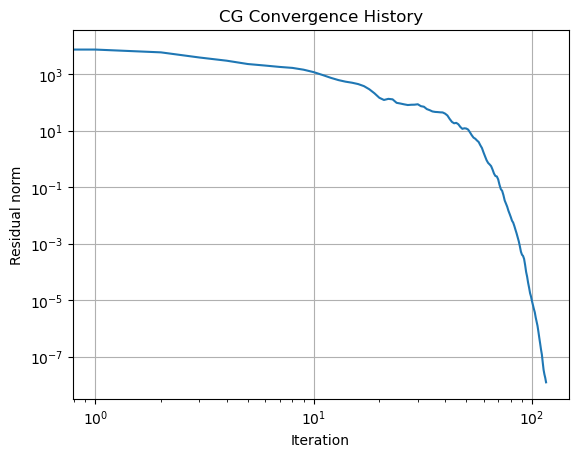

In [7]:
plt.loglog(residuals)
plt.xlabel("Iteration")
plt.ylabel("Residual norm")
plt.title("CG Convergence History")
plt.grid(True)
plt.show()

In [8]:
def smooth(U: np.ndarray, omega: float, m: int, F: np.ndarray):
    '''
        Under/over relaxed JACOBI SMOOTHENER

        # Input
            U: flattened grid vector to be smoothened. Should be enumerated: k := i + j*m
            omega: realxation parameter
            m: number of interior points in each direction (x,y)
            F: RHS vector with boundary corrections
            u_func: DC boundary analytical function
        # Output
            Unew: updated U vector after a single step of smoothening
    '''
    h = 1.0/(m+1)
    Unew = np.copy(U)

    for j in range(m):
        for i in range(m):
            k = i + j*m
            x = (i + 1) * h
            y = (j + 1) * h

            left  = U[k-1] if i > 0   else 0.0 # TODO: fix that boundary value is fixed for this problem
            right = U[k+1] if i < m-1 else 0.0 # TODO: same
            down  = U[k-m] if j > 0   else 0.0 # TODO: same
            up    = U[k+m] if j < m-1 else 0.0 # TODO: same

            Unew[k] = (
                (1-omega)*U[k]
                + omega/4 * (left + right + up + down -h**2 * F[k])
            )

    return Unew

In [9]:
def exact_solution(m, u_func):
    h = 1/(m+1)
    Ue = np.zeros(m*m)

    for j in range(m):
        for i in range(m):
            x = (i+1)*h
            y = (j+1)*h
            Ue[i +j*m] = u_func(x, y)

    return Ue

In [10]:
m = 50
omega = 2/3
iters = 1000

F = form_rhs(m, f_func, u_func)
U = np.zeros(np.size(F))
print(F.shape, U.shape)
h = 1/(m+1)
U_exact = exact_solution(m, u_func)
# print(F)

(2500,) (2500,)


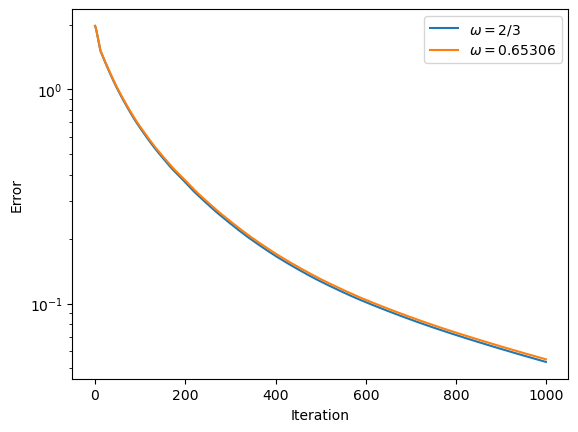

In [11]:
errors = []

U = np.zeros(np.size(F))
for k in range(iters):
    U = smooth(U, omega, m, F)

    err = np.linalg.norm(U - U_exact, np.inf)  # infinity norm
    #err = h*np.linalg.norm(U - U_exact, 2)  # L2-norm
    errors.append(err)

omega = 0.65306
errors2 = []

U = np.zeros(np.size(F))
for k in range(iters):
    U = smooth(U, omega, m, F)
    
    err = np.linalg.norm(U - U_exact, np.inf)  # infinity norm
    #err = h*np.linalg.norm(U - U_exact, 2)  # L2-norm
    errors2.append(err)

plt.semilogy(errors, label=rf"$\omega = 2/3$")
plt.semilogy(errors2, label=rf"$\omega = {omega}$")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.legend()
plt.show()

In [12]:
def exact_solution(m, u_func):
    h = 1/(m+1)
    Ue = np.zeros(m*m)

    for j in range(m):
        for i in range(m):
            x = (i+1)*h
            y = (j+1)*h
            Ue[i +j*m] = u_func(x, y)

    return Ue

In [13]:
def coarsen(R, m):
    mc = m // 2
    Rc = np.empty(mc**2)

    # Half weighting
    for kc in range(mc**2):
        '''
            ic = kc % mc
            jc = kc // mc
            k = 2ic + 2*jc*m 
            k = 2*kc
            k = i + j*m = 2*kc
            (i ± 1, j) = k ± 1 = 2*kc ± 1
            (i, j ± 1) = k ± m = 2*kc ± m
        '''

        ic, jc = kc % mc, kc // mc
        k = 2 * ic + 2 * jc * m

        center = R[k]
        left  = R[k-1]  if 2*ic > 0     else 0.0 # trivially true
        right = R[k+1]   if 2*ic < m-1   else 0.0
        up  = R[k-m]  if 2*jc > 0     else 0.0 # trivially true
        down    = R[k+m]   if 2*jc < m-1   else 0.0
        
        Rc[kc] = 1 / 8 * (
            left # (i - 1, j)
            + up # (i, j - 1)
            + 4 * center # (i, j)
            + down # (i, j + 1)
            + right # (i + 1, j)
        )
    return Rc

def interpolate(Rc, m):
    mc = m//2
    coarse = Rc.reshape(mc, mc)
    fine = np.zeros(m**2)
    fine.reshape(m,m)[::2, ::2] = coarse
    for k in range(m**2):
        i = k % m
        j = k // m
        if (i % 2 == 0) and (j % 2 == 0):
            continue
        elif (i % 2 == 0):
            up = coarse[(j - 1) // 2, i // 2]   if (j - 1) // 2 >= 0 else 0.0
            down = coarse[(j + 1) // 2, i // 2] if (j + 1) // 2 < mc else 0.0
            fine[k] = 0.5 * (up + down)
        elif (j % 2 == 0):
            left = coarse[j // 2, (i - 1) // 2]  if (i - 1) // 2 >= 0 else 0.0
            right = coarse[j // 2, (i + 1) // 2] if (i + 1) // 2 < mc else 0.0
            fine[k] = 0.5 * (left + right)
        else:
            nw = coarse[(j - 1) // 2, (i - 1) // 2]   if ((j - 1) // 2 >= 0) and ((i - 1) // 2 >= 0) else 0.0
            sw = coarse[(j + 1) // 2, (i - 1) // 2] if ((j + 1) // 2 < mc) and ((i - 1) // 2 >= 0) else 0.0
            ne = coarse[(j - 1) // 2, (i + 1) // 2] if ((j - 1) // 2 >= 0) and ((i + 1) // 2 < mc) else 0.0
            se = coarse[(j + 1) // 2, (i + 1) // 2] if ((j + 1) // 2 < mc) and ((i + 1) // 2 < mc) else 0.0
            fine[k] = 0.25 * (nw + sw + ne + se)
    return fine

In [14]:
Amult()

TypeError: Amult() missing 2 required positional arguments: 'U' and 'm'

In [ ]:
def VCM(Amult, R, P, u, f, l):
    if l == 1:

        
def residual(U, F, m):
    return - F - Amult(U, m)


In [ ]:
u0 =  
k_max = 

u = u0
r = residual(F, u, m)
k = 0
while np.linalg.norm(r, 2) and k < k_max:
    u = VCM(Amult,coarsen,interpolate,u,F,l )
    r = residual(F, u, m)


